# Exploratory Data Analysis (EDA) of The Original Dataset

Based on our inspection and analysis in this notebook we'll continue the next steps in the other notebooks corresponding the purpose of each one.
- Traditional ML Models for Classificaton `HDP-CLS-ML.ipynb`
- Artificial Neural Networks for Classificaton `HDP-CLS-ANN.ipynb`
- Traditional ML Models for Regression`Reg-ML-ORG.ipynb`
- Artificial Neural Networks for Regression`Reg-ANN-ORG.ipynb`


### 1) Import Libraries

In [1]:
# Import libraries and modules

# ---------- path setup ----------
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "Notebooks"))
DATA_DIR = PROJECT_ROOT / "Data/main_dataset"


#----- Tools, visualizers -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from utils import *


### 2) Load Data and Inspect

In [38]:
#---------------
# Load dataset
#---------------
data = pd.read_csv(DATA_DIR / "heart-data.csv")
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
#-----------------
# Inspect & Info
#-----------------

# Get info and statistics
print(data.info())
print(data.describe().T)
print(20*"--")
# Check shape of the dataset
print(f"Shape of the dataset: {data.shape}")
# Count missing values
print(f"Counts of missing values:\n{data.isna().sum()}")
# Count duplicated values
print(f"Counts of duplicated values: {data.duplicated().sum()}")
# Check uniqueness of values
# Count unique values in each col
print(data.nunique())
# Get columns & their unique values
unique_values = {col: data[col].unique().tolist()
                  for col, value in zip(data.columns.tolist(), data.nunique()) if value <= 4}
unique_values

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None
              count        mean         std   min     25%    50%    75%    max
Age           918.0   53.510893    9.432617  28.0   47.00   54.0   60.0   77.0
RestingBP     918.0  132.396514   18.514154   0.0  120

{'Sex': ['M', 'F'],
 'ChestPainType': ['ATA', 'NAP', 'ASY', 'TA'],
 'FastingBS': [0, 1],
 'RestingECG': ['Normal', 'ST', 'LVH'],
 'ExerciseAngina': ['N', 'Y'],
 'ST_Slope': ['Up', 'Flat', 'Down'],
 'HeartDisease': [0, 1]}

### Check impossible ranges and categorical values

When preparing data, it’s essential to validate whether values fall into *feasible ranges* and whether categorical features contain *unexpected values*. This step helps detect data entry errors, anomalies, or artifacts that could negatively affect the model.

- **Numeric features (impossible ranges):**  
  Certain columns have real-world physical or medical constraints. For example,  
  - Age should not be negative or unrealistically high (e.g., >120).  
  - RestingBP (resting blood pressure) cannot be zero or negative.  
  - Cholesterol cannot be zero (unless missing encoded badly).  
  - MaxHR (maximum heart rate) should not exceed 220 − age.  
  - Oldpeak (ST depression) should not be negative.  

  By checking these conditions, we can identify impossible or highly unlikely values.

- **Categorical features (unexpected values):**  
  For object/string features, we validate that categories belong to a known, limited set.  
  Example: "Sex" should only contain `M` or `F`. If we detect other categories (e.g., typos like `m`, `male`, `?`), they need to be handled.  

  This ensures categorical variables are clean and consistent, avoiding issues when encoding them later.


**In summary:**  
Checking ranges for numeric features prevents impossible values from biasing the model, while checking category distributions ensures data quality and avoids errors during preprocessing (like encoding).


### 3) Divide dataset by columns types

In [39]:
#---------------------------------------------------------------------------------
# Divide dataset into two different dataset 
# based on two types `Number` & `Object` and `Numeric` & `categorical` -> Only to check easily and quickly
#---------------------------------------------------------------------------------

# numerical features type (Only Continuous; So `FastingBS` & `HeartDisease` should be dropped)
num_cols = data.select_dtypes(include='number').drop(columns=['FastingBS', 'HeartDisease'], errors='ignore')
# Categorical features:  Object features type + `FastingBS`
obj_cols = data.select_dtypes(include=['object', 'string'])
cat_cols = pd.concat([obj_cols, data['FastingBS']], axis=1)
print(num_cols.head())
print(cat_cols.head())

   Age  RestingBP  Cholesterol  MaxHR  Oldpeak
0   40        140          289    172      0.0
1   49        160          180    156      1.0
2   37        130          283     98      0.0
3   48        138          214    108      1.5
4   54        150          195    122      0.0
  Sex ChestPainType RestingECG ExerciseAngina ST_Slope  FastingBS
0   M           ATA     Normal              N       Up          0
1   F           NAP     Normal              N     Flat          0
2   M           ATA         ST              N       Up          0
3   F           ASY     Normal              Y     Flat          0
4   M           NAP     Normal              N       Up          0


### 4) Check labels (calsses) column distribution

HeartDisease
1    508
0    410
Name: count, dtype: int64


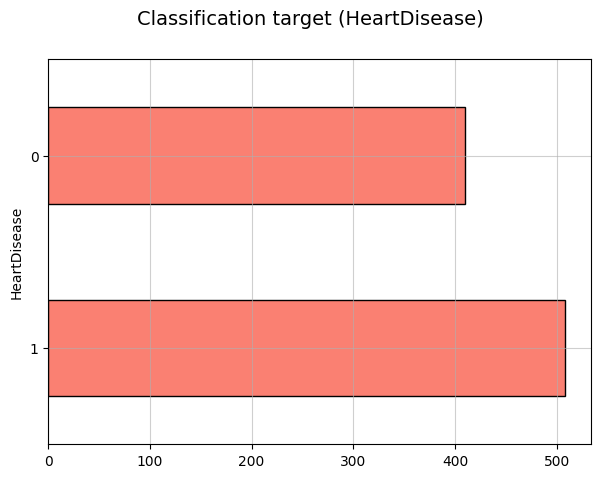

In [8]:
#-----------------------------------------
# Get the exact counts and visualize them
#-----------------------------------------

# Get the class column
target_col = data['HeartDisease'].value_counts()
# Adjust the plot
plt.figure(figsize=(7, 5))
target_col.plot.barh(color='salmon', edgecolor='k')
plt.suptitle("Classification target (HeartDisease)", fontsize=14)
plt.grid(alpha=0.6)
# Print exact counts
print(target_col)

> The distribution of classes is fairly good and appropriate.

### 5) Check features columns distribution

In [6]:
#-------------------------------------
# Count values of categorical features 
#-------------------------------------

# Get object categorical features 
features = cat_cols
# Print each column's value counts
for f in features:
    print(data[f].value_counts())
    print(data[f].value_counts(normalize=True))
    print(20*"---")

Sex
M    725
F    193
Name: count, dtype: int64
Sex
M    0.78976
F    0.21024
Name: proportion, dtype: float64
------------------------------------------------------------
ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64
ChestPainType
ASY    0.540305
NAP    0.221133
ATA    0.188453
TA     0.050109
Name: proportion, dtype: float64
------------------------------------------------------------
RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64
RestingECG
Normal    0.601307
LVH       0.204793
ST        0.193900
Name: proportion, dtype: float64
------------------------------------------------------------
ExerciseAngina
N    547
Y    371
Name: count, dtype: int64
ExerciseAngina
N    0.595861
Y    0.404139
Name: proportion, dtype: float64
------------------------------------------------------------
ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64
ST_Slope
Flat    0.501089
Up      0.430283
Down    0.068627
Name

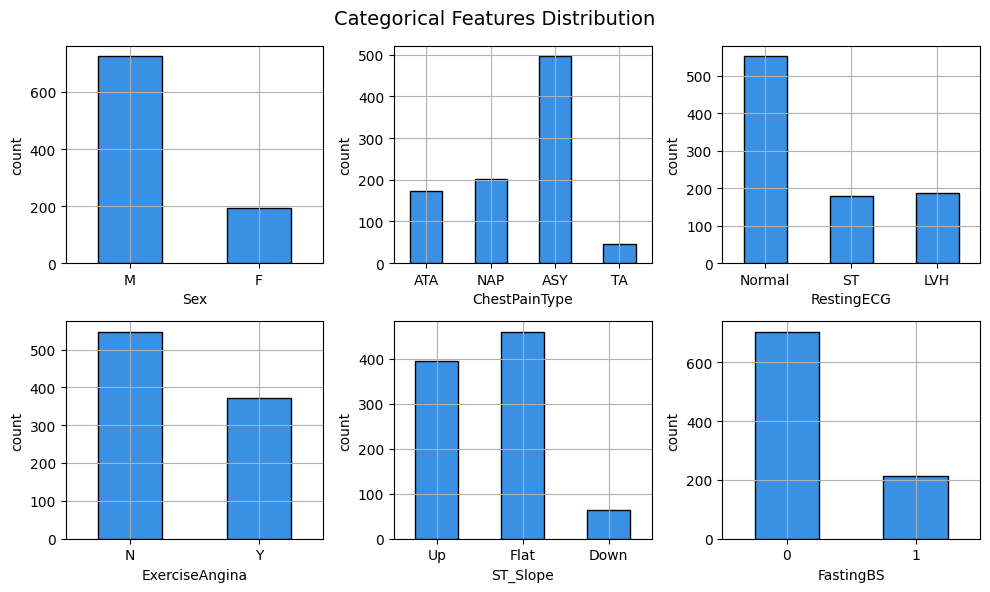

In [10]:
#-----------------------------------------
# Object features distribution using bars
#-----------------------------------------

# Create figure and its size/shape
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

# Flatten axes array for easy looping
axes = axes.flatten()

# Loop through the dataframe and get (index, column)
for i, col in enumerate(cat_cols):
    # Adjust the plot
    sns.countplot(x=col, data=cat_cols, ax=axes[i], width=0.5,
                   color='dodgerblue', edgecolor='black')
    # Add grids
    axes[i].grid()

# If there are empty subplots, remove them
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Categorical Features Distribution", fontsize=14)
plt.tight_layout()
plt.show()

> The distribution of object categorical features is sort of good; We can leave them as are, or do some feature engineering such as merging the rare features with similar ones just in case! 
- But We keep them as they are.

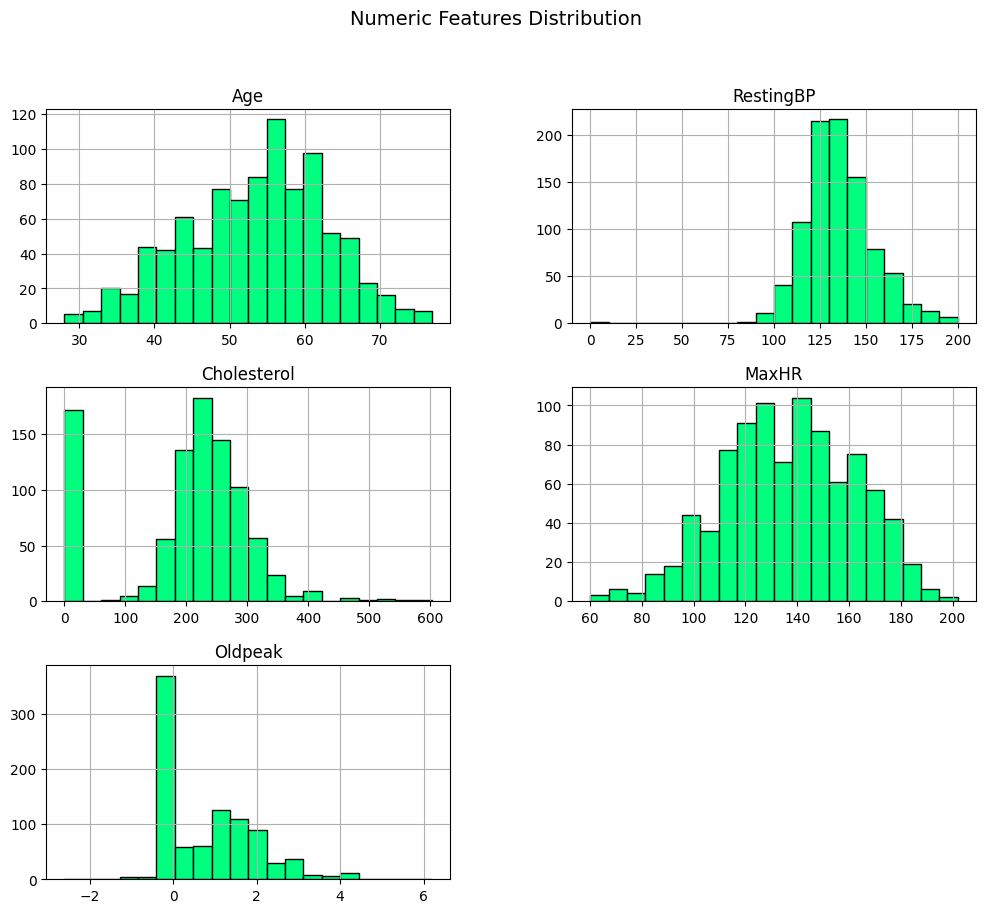

In [12]:
#------------------------------------------------------------
# Continuous numerical features distribution using Histogram
#------------------------------------------------------------

# Visualize features distribution
num_cols.hist(
    figsize=(12, 10), 
    color='springgreen',
    edgecolor='black',
    bins=20
)

plt.suptitle("Numeric Features Distribution", fontsize=14)
plt.show()

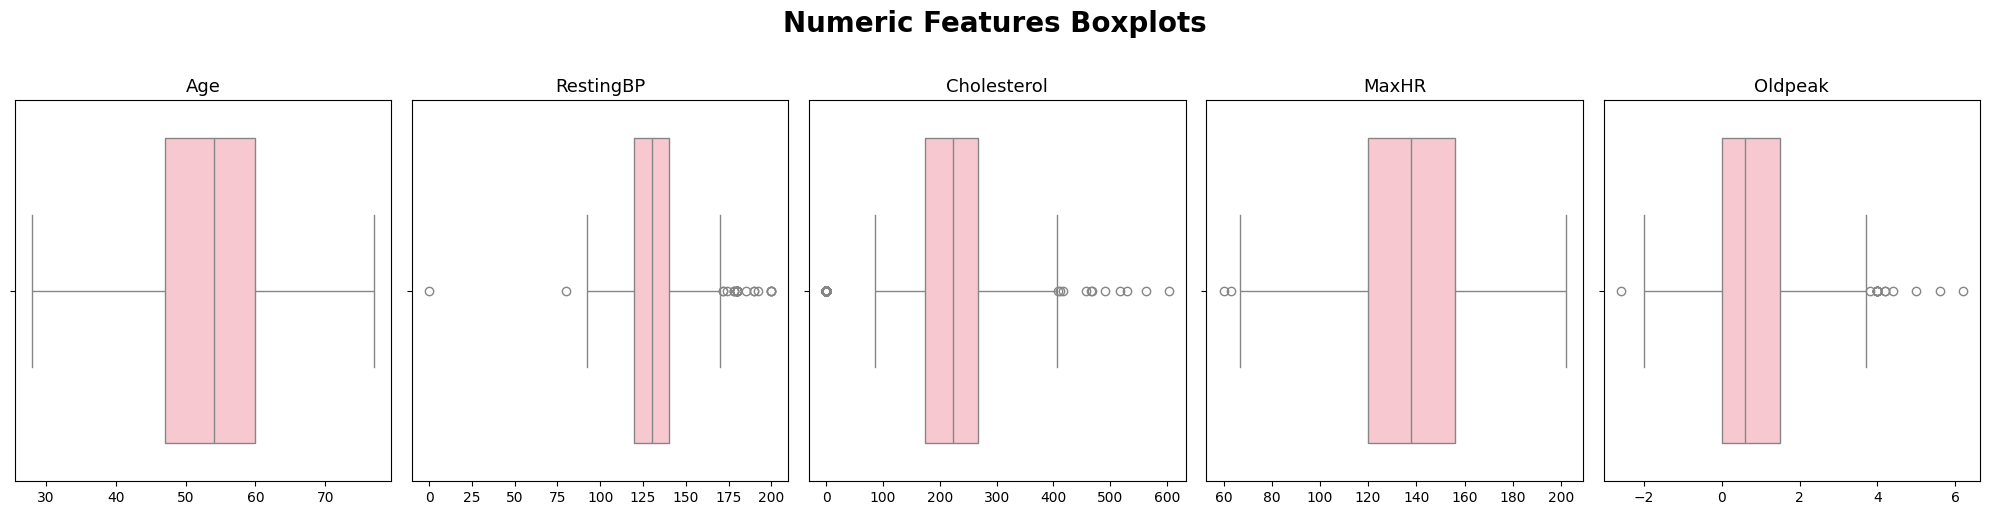

In [ ]:
#----------------------------------------------
# Visualize numeric features by using Boxplot
#----------------------------------------------

def boxplot(train, color="pink", title="Numeric Features Boxplots"):
    # Figure
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    axes = axes.flatten()
    # Visualize
    for i, col in enumerate(train):
        sns.boxplot(data=train, x=col, ax=axes[i], color=color)
        axes[i].set_title(col, fontsize=13)
        axes[i].set_xlabel("")  # Remove x-labels for clean look

    plt.suptitle(title, fontsize=20, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

boxplot(num_cols)


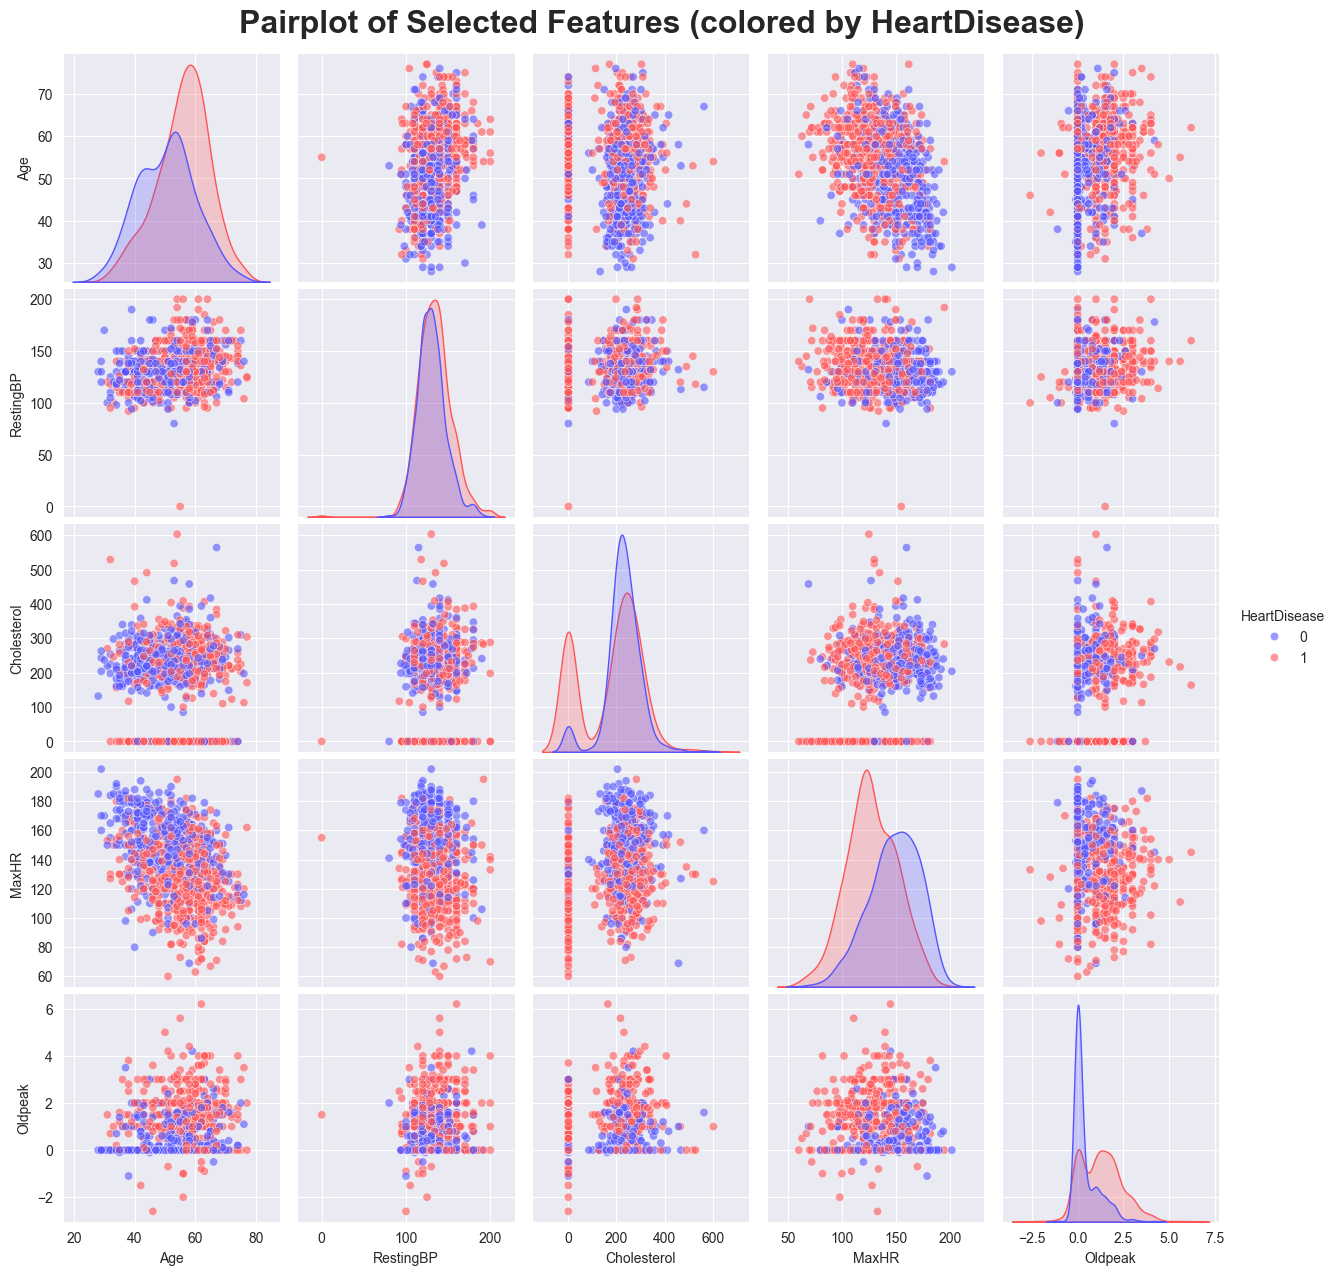

In [ ]:
#----------------------------------------------
# Visualize pairplots -> Target: HeartDisease
#----------------------------------------------

# Features + the cat target (HD)
selected1 = num_cols.columns.tolist() + ["HeartDisease"]

# Visualize pairplots
sns.set_style("darkgrid")
sns.pairplot(
    data[selected1],
    hue="HeartDisease",
    palette="seismic",
    plot_kws={'alpha': 0.6},
    diag_kind="kde"
)

plt.suptitle("Pairplot of Selected Features (colored by HeartDisease)",
              fontsize=23, fontweight="bold", y=1.02)
plt.show()


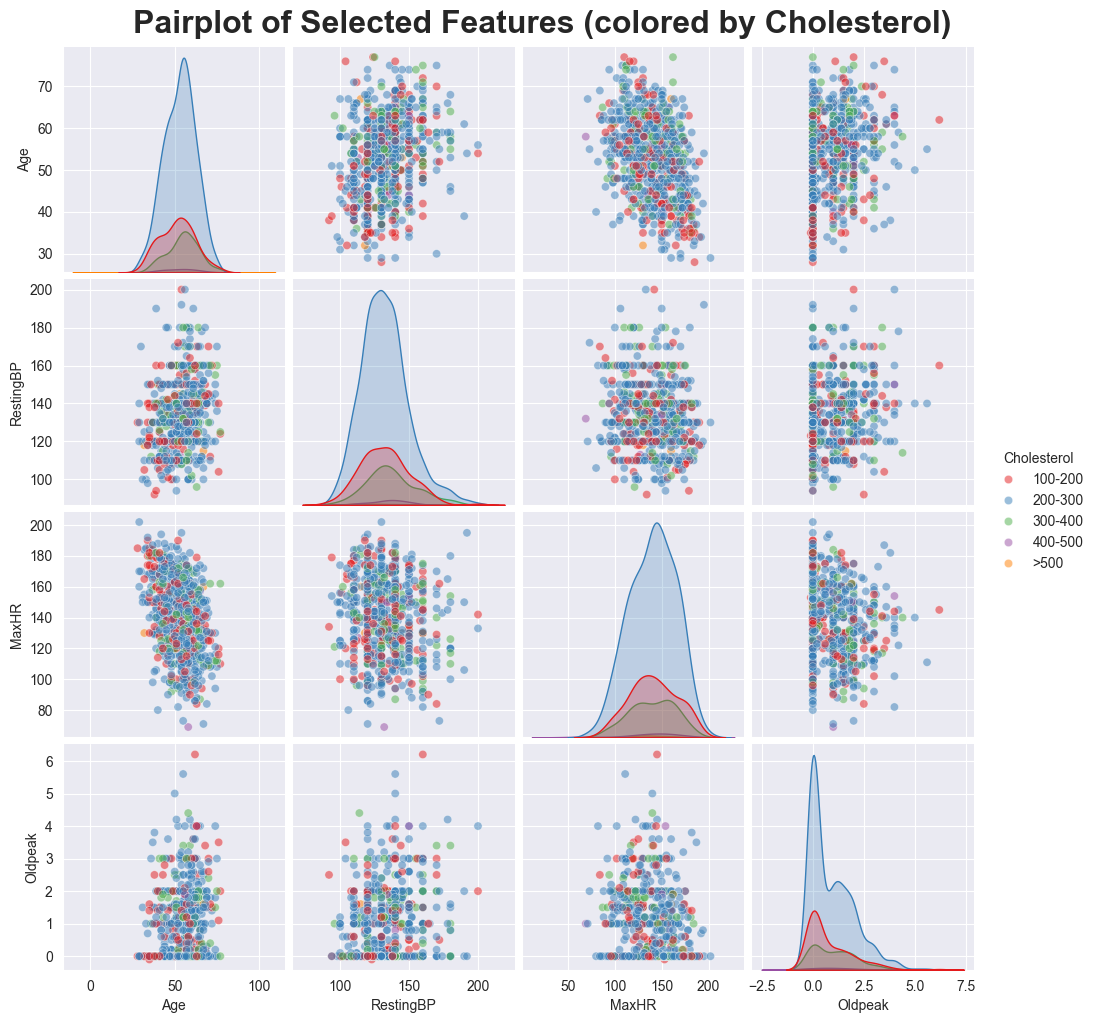

In [ ]:
#--------------------------------------
# Visualize pairplots -> Target: Chol
#--------------------------------------

# Make a copy of external data
data_copy = data.copy()
# Categorize `Chol` into 5 categories
data_copy['Cholesterol'] = pd.cut(data_copy['Cholesterol'], bins=[100, 200, 300, 400, 500, 600],
                            labels=['100-200', '200-300', '300-400', '400-500', '>500'])

# Features + the target
num_cols_copy = num_cols.copy()
num_cols_copy.drop(columns=['Cholesterol'], inplace=True)
selected2 = num_cols_copy.columns.tolist() + ['Cholesterol']

# Visualize pairplots
sns.set_style("darkgrid")
sns.pairplot(
    data_copy[selected2],
    hue="Cholesterol",
    palette="Set1",
    plot_kws={'alpha': 0.5},
    diag_kind="kde"
)

plt.suptitle("Pairplot of Selected Features (colored by Cholesterol)",
              fontsize=23, fontweight="bold", y=1.02)
plt.show()



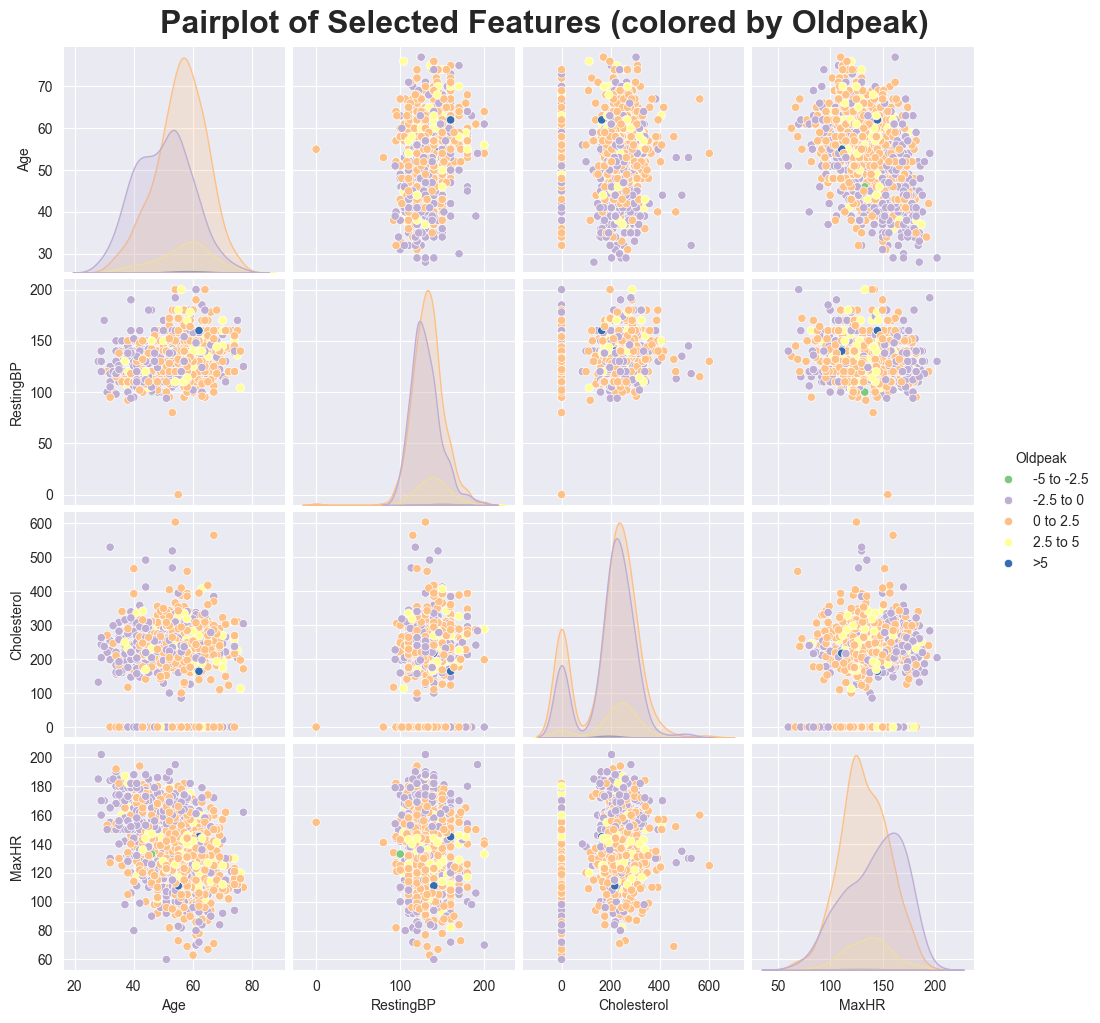

In [ ]:
#----------------------------------------
# Visualize pairplots -> Target: Oldpeak
#----------------------------------------

# Make a copy of external data
data_copy = data.copy()
# Categorize `Oldpeak` into 5 categories
data_copy['Oldpeak'] = pd.cut(data_copy['Oldpeak'], bins=[-5, -2.5, 0, 2.5, 5, 10],
                            labels=['-5 to -2.5', '-2.5 to 0', '0 to 2.5', '2.5 to 5', '>5'])

# Features + the target
num_cols_copy = num_cols.copy()
num_cols_copy.drop(columns=['Oldpeak'], inplace=True)
selected3 = num_cols_copy.columns.tolist() + ['Oldpeak']

# Visualize pairplots
sns.set_style("darkgrid")
sns.pairplot(
    data_copy[selected3],
    hue="Oldpeak",
    palette="Accent",
    plot_kws={'alpha': 1},
    diag_kind="kde"
)

plt.suptitle("Pairplot of Selected Features (colored by Oldpeak)",
              fontsize=23, fontweight="bold", y=1.02)
plt.show()



> By looking at the plots including histograms, boxplots and pairplot, we can get a general idea of which numerical feature needs more inspection.
- Numerical Features need more inspections are as following:
    - RestingBP 
        - < 40 = unlikely (coma territory) | 250 <= extremely rare, maybe an error.
    - Cholesterol
        - < 80 = very suspicious | 700 <= probably measurement/entry error.
    - Oldpeak
        - range should be 0–6 | Negative values don’t make sense & 7–8 is very unlikely.

In [13]:
#---------------------------------------------------------------
# Check the features at hand further (Counts of unlikely values)
#---------------------------------------------------------------

#--RestingBP--
print('RestingBP:')
print(f"Counts of (< 40): {(num_cols['RestingBP'] < 40).sum()}",
        f"\nCounts of (>= 250): {(num_cols['RestingBP'] >= 250).sum()}\n{20*'--'}")

#--Cholesterol--
print('Cholesterol:')
print(f"Counts of (< 80): {(num_cols['Cholesterol'] < 80).sum()}",
        f"\nCounts of (>= 500): {(num_cols['Cholesterol'] > 500).sum()}\n{20*'--'}")

#--Oldpeak--
print('Oldpeak:')
print(f"Counts of (< 0): {(num_cols['Oldpeak'] < 0).sum()}",
        f"\nCounts of (>= 7): {(num_cols['Oldpeak'] >= 7).sum()}")



RestingBP:
Counts of (< 40): 1 
Counts of (>= 250): 0
----------------------------------------
Cholesterol:
Counts of (< 80): 172 
Counts of (>= 500): 4
----------------------------------------
Oldpeak:
Counts of (< 0): 13 
Counts of (>= 7): 0


### 6) Check skewness and outliers of numerical features


**Threshold of skewness:**

- |skew| < 0.5 →  Almost symmetric → leave it as is

- 0.5 ≤ |skew| < 1 →  Moderate skew → consider transforming (if it matters for your model)

- |skew| ≥ 1 →  High skew → strongly consider transformation

> The following functions `skewness_detector` & `outliers_detector` for detecting skewness and outliers are written in `utils.py` for usability.

In [12]:
#----------------
# Check skewness
#----------------

skewness_detector(num_cols)

,Feature,Skewness,Skewness_Exceeding_Threshold
0,Age,0.195933,False
1,RestingBP,0.179839,False
2,Cholesterol,0.610086,False
3,MaxHR,0.144359,False
4,Oldpeak,1.022872,True


In [13]:
#-------------------------------------------
# Find potential outliers in numeric values
#-------------------------------------------

outlier_detector(num_cols)


,Feature,N_outliers,Outlier_pct
2,Cholesterol,183,19.935
1,RestingBP,28,3.050
4,Oldpeak,16,1.743
3,MaxHR,2,0.218
0,Age,0,0.000


### 7) Check correlations of features and classes
- Numeric ↔ Numeric Correlations
- Categorical ↔ Categorical Correlations
- Categorical ↔ Numeric Correlations
- Feature ↔ Target Correlations
    - Continuous Numeric features ↔ Target
    - Categorical features ↔ Target

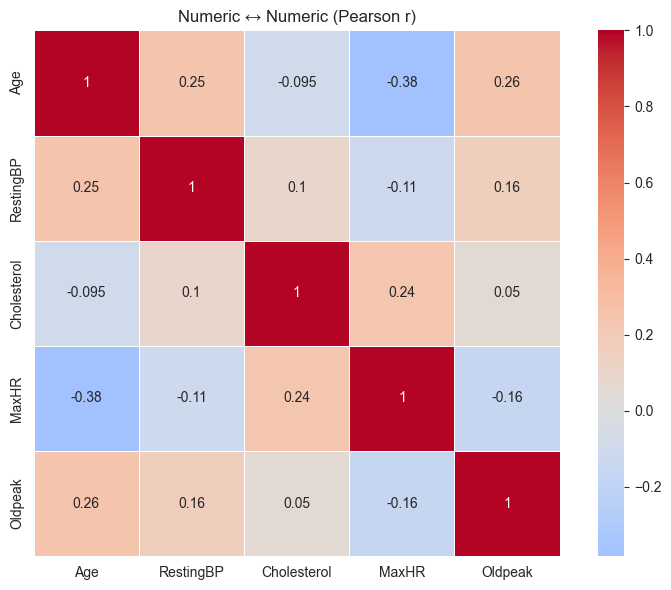

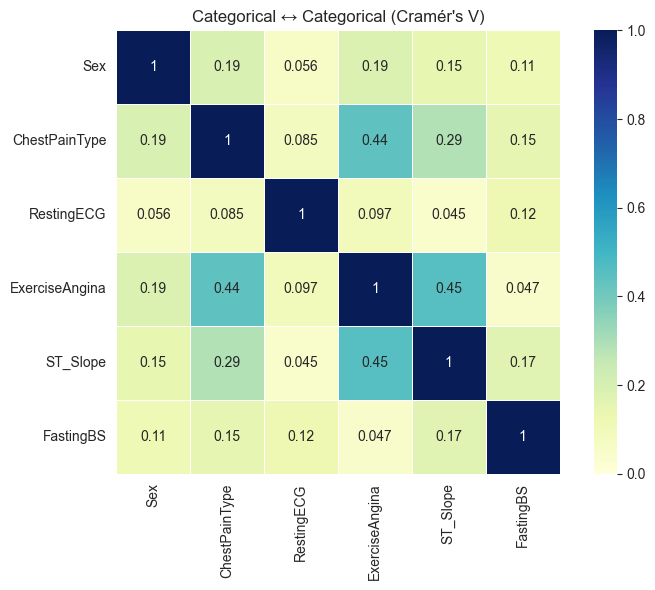

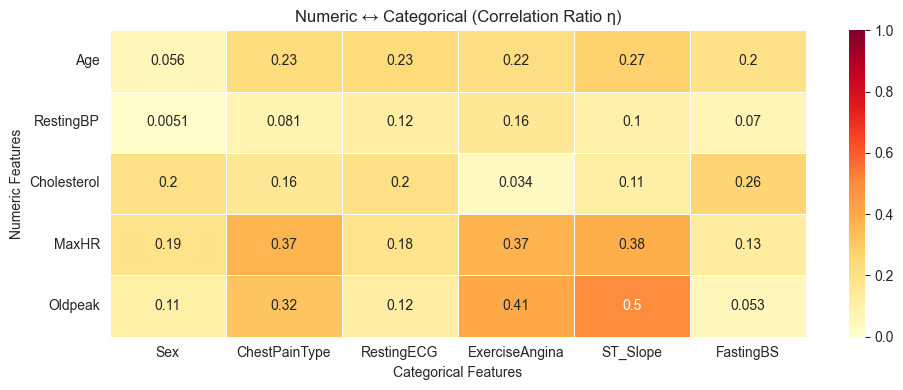

e:\Python_3_13\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\ALP Computer\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


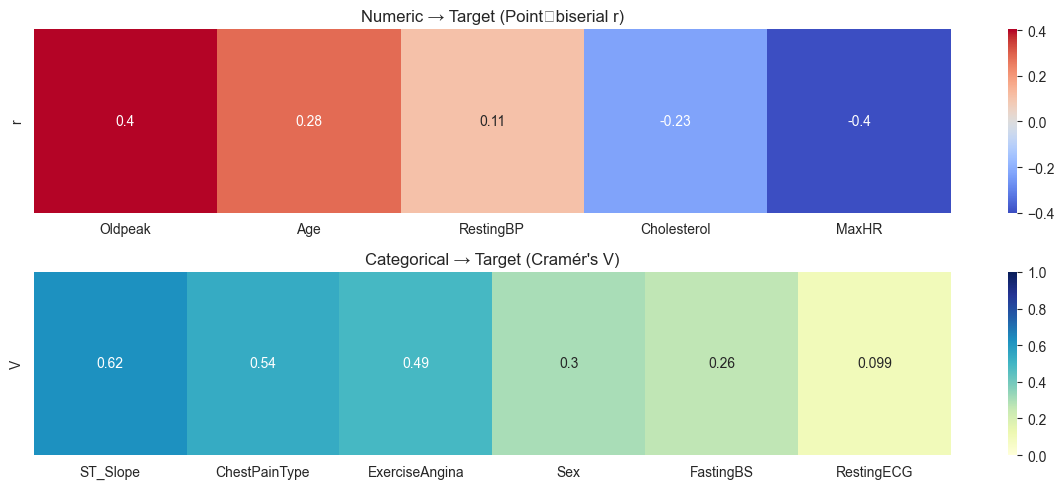

In [40]:
# Get columns name as lists
numeric_features = num_cols.columns.tolist()
categorical_features = cat_cols.columns.tolist()

analyzerHD = CorrelationAnalyzer(
    data=data,
    target_type='categorical',
    num_cols=numeric_features,
    cat_cols=categorical_features,
    target_col='HeartDisease'
)

analyzerHD.plot_all()

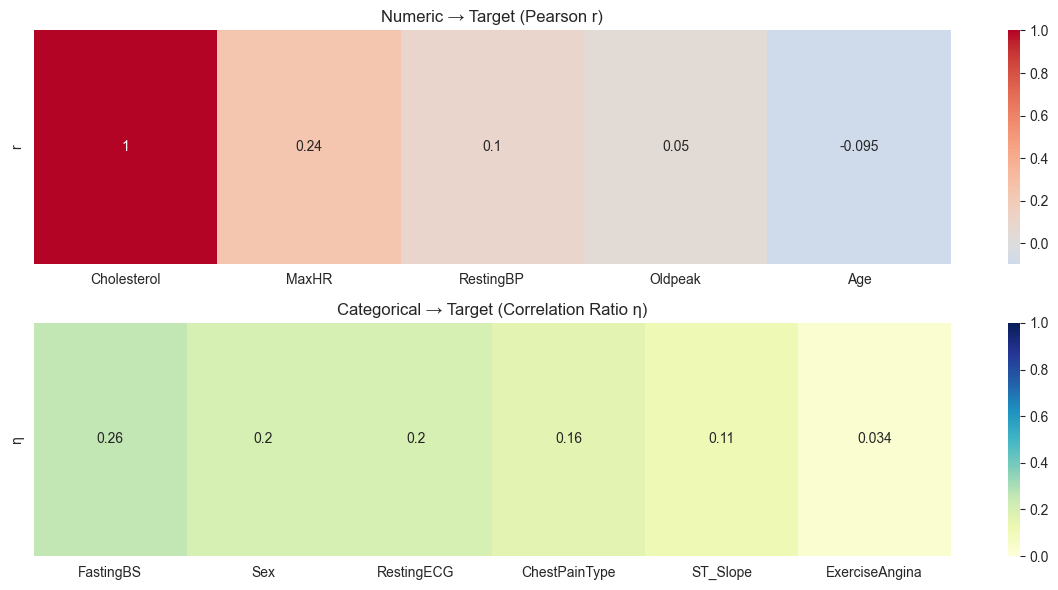

In [41]:
# Get columns name as lists
numeric_features = num_cols.columns.tolist()
categorical_features = cat_cols.columns.tolist()

analyzerCH = CorrelationAnalyzer(
    data=data,
    target_type='numeric',
    num_cols=numeric_features,
    cat_cols=categorical_features,
    target_col='Cholesterol'
)

analyzerCH.plot_feature_numeric_target()

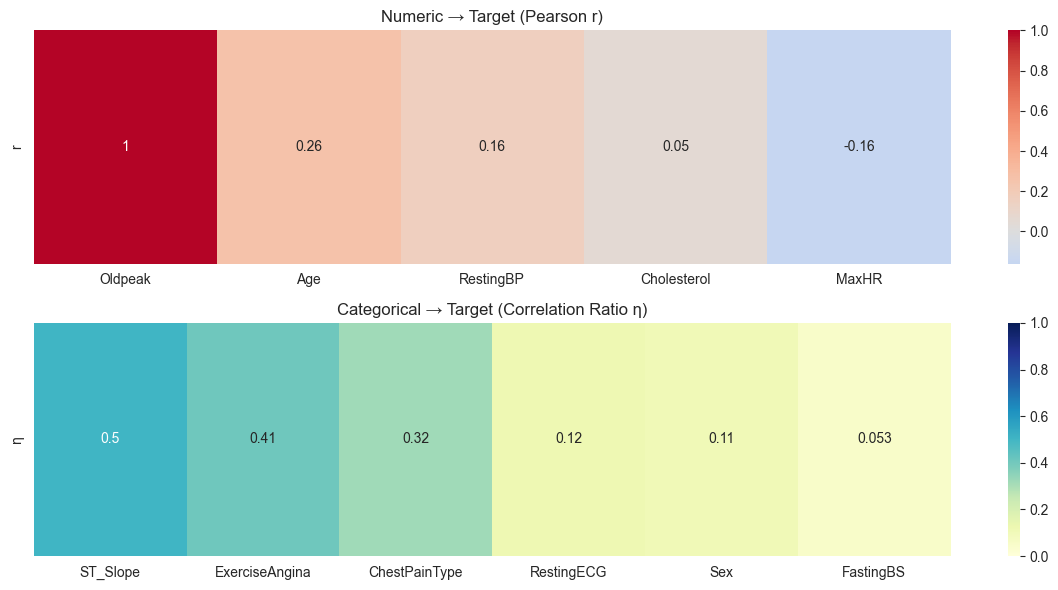

In [42]:
# Get columns name as lists
numeric_features = num_cols.columns.tolist()
categorical_features = cat_cols.columns.tolist()

analyzerOL = CorrelationAnalyzer(
    data=data,
    target_type='numeric',
    num_cols=numeric_features,
    cat_cols=categorical_features,
    target_col='Oldpeak'
)

analyzerOL.plot_feature_numeric_target()

### 8) Split the dataset into train and test

In [16]:
from sklearn.model_selection import train_test_split

# Keep 15% as final test set
train_set, test_set = train_test_split(data, test_size=0.15,
                                       random_state=42, stratify=data['HeartDisease'])

train_set.to_csv(DATA_DIR / "train_set.csv", index=False)
test_set.to_csv(DATA_DIR / "test_set.csv", index=False)

print(f"Train set: {len(train_set)}  |  Test set: {len(test_set)}")

Train set: 780  |  Test set: 138
